# 損失の可視化

## データをロード

In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import json
import os

def load_data(path, file="training_history.json"):
    path = os.path.join(path, file)
    print(f"Loading data from: {path}")
    # JSONファイルを読み込む
    with open(path, "r") as f:
        data = json.load(f)
    return data

def show_json_info(json_path, keys=None):
    """
    JSONファイルの内容を表示する関数。
    keys を None にすると全項目を表示。
    keys にリストを渡すと、その項目だけ表示。
    """
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"[Error] File not found: {json_path}")
        return
    except json.JSONDecodeError:
        print(f"[Error] Invalid JSON format: {json_path}")
        return

    # print(f"=== {json_path} ===")

    # keysが指定されていない場合 → 全項目出力
    if keys is None:
        for key, value in data.items():
            print(f"{key}: {value}")
    else:
        # 指定されたキーのみ出力
        for key in keys:
            if key in data:
                print(f"{key}: {data[key]}")
            else:
                print(f"{key}: [キーが存在しません]")


In [35]:
import os

col = [
    '#e41a1c',  # 赤
    '#4daf4a',  # 緑
    '#377eb8',  # 青
    '#ff7f00',  # オレンジ
    '#ffff33',  # 黄色
    '#a65628',  # 茶
    '#984ea3'   # 紫（最後）
    '#f781bf',  # ピンク
]


# 共通のroot（students用）
root = os.path.join("..", "save", "students", "models")

In [ ]:
files = {
    "VGG16-half (Vanilla KD)": [

    ],

    "VGG16-half (Str-KD)": [
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251225_194324",

    ],
    "ResNet14 (Vanilla KD)": [
"S_resnet14-T_resnet14x2-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251225_205125",

    ],
    "ResNet14 (Str-KD)": [
    ],
}

keys = [
    "train_loss_total",
    "train_loss_cls",
    "train_loss_div",
    "train_loss_kd",
    # "train_loss_kd_group"
]

Processing: VGG16-half (Vanilla KD)
Processing: VGG16-half (Str-KD)
Loading from: ..\save\students\models\S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251225_132403
Loading data from: ..\save\students\models\S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251225_132403\training_history.json
Loading from: ..\save\students\models\S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251225_132403
Loading data from: ..\save\students\models\S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251225_132403\training_history.json
[[0.31224633811950686, 0.21370007044792175, 0.18092324130058288, 0.16146972290515899, 0.14778274203300476, 0.1380922803068161, 0.13078987496376038, 0.12471841929197311, 0.12052765240430832, 0.116676162109375, 0.11374353357076646, 0.11042276226520538, 0.1086397680234909, 0.10634976697206497

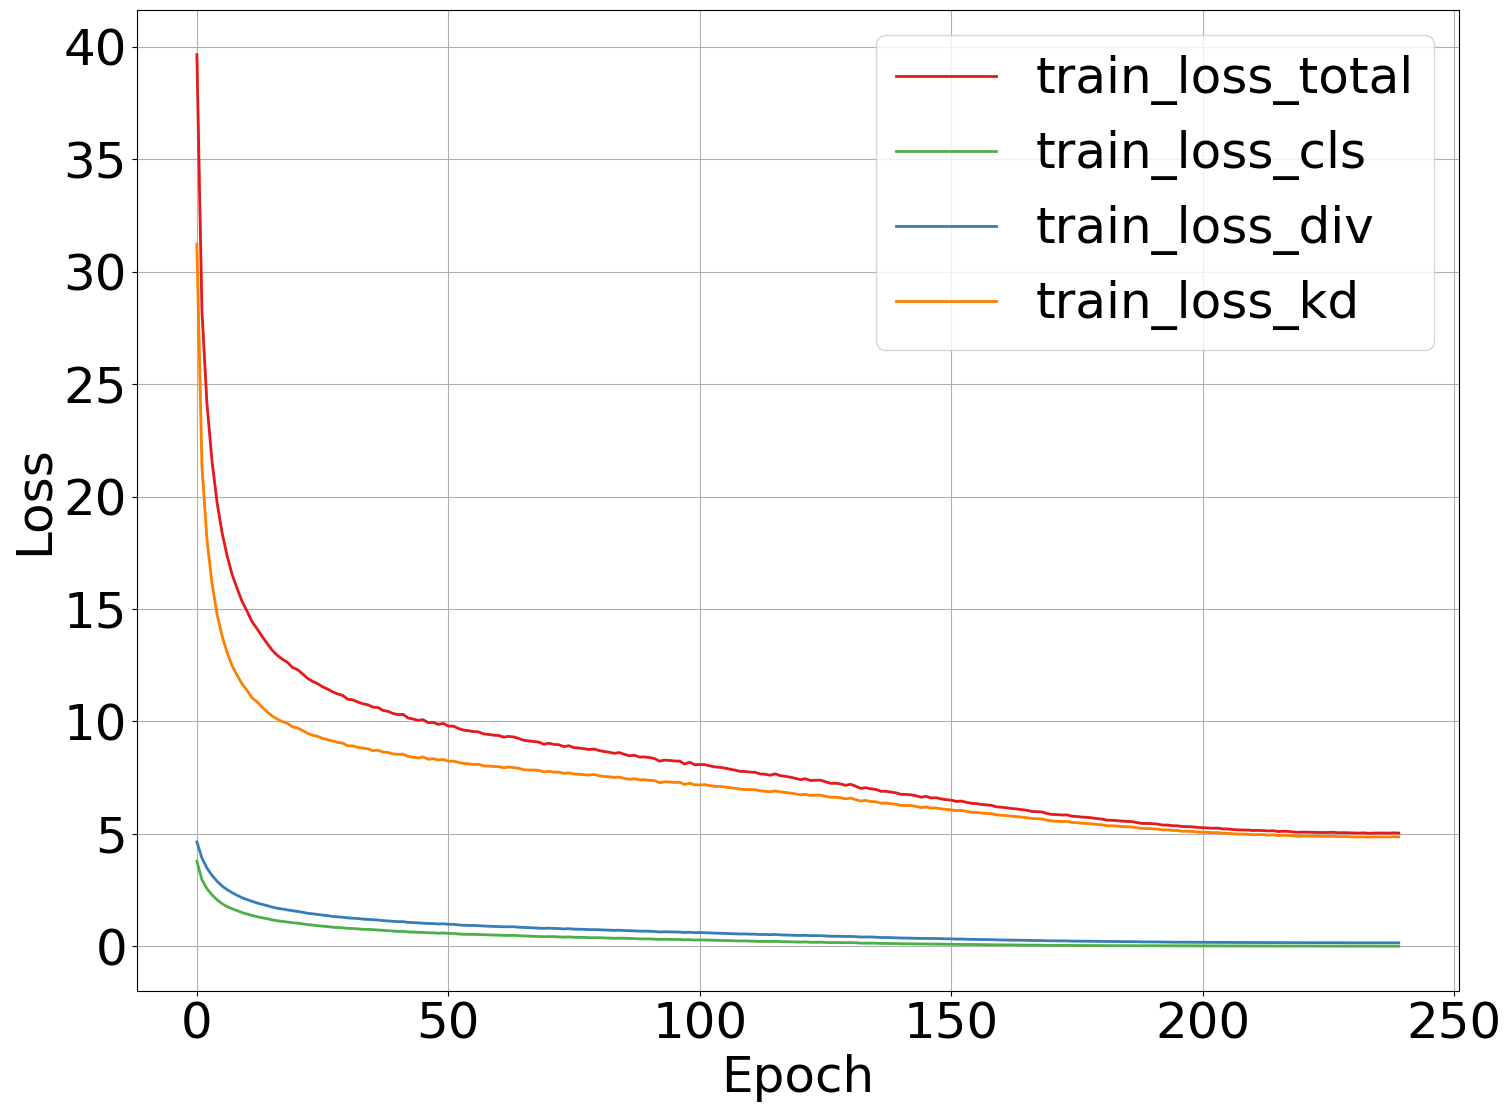

Processing: ResNet14 (Vanilla KD)
Loading from: ..\save\students\models\S_resnet14x2-T_resnet14x2-cifar100-trial_0-epochs_240-bs_64-hint-cls_1.0-div_1.0-beta_1.0-20251225_042255
Loading data from: ..\save\students\models\S_resnet14x2-T_resnet14x2-cifar100-trial_0-epochs_240-bs_64-hint-cls_1.0-div_1.0-beta_1.0-20251225_042255\training_history.json
[[0.07028017346143722, 0.018890077893733977, 0.015941541615724565, 0.014813322642445564, 0.01419233668744564, 0.013855271829664707, 0.013602969235777855, 0.013490117515921593, 0.013359400564432144, 0.013241699382066726, 0.01310784032136202, 0.01299197867691517, 0.012868673116564752, 0.012733288769721985, 0.012621732849478722, 0.012496794333457947, 0.01237756548523903, 0.012274066396355629, 0.012166766583025455, 0.012070600258708, 0.01196026359140873, 0.011830972071290016, 0.011704959167540073, 0.01155888506680727, 0.011428969189822674, 0.011301852656304836, 0.01121129819869995, 0.011146495868861675, 0.011073686213493347, 0.011012637092471123, 

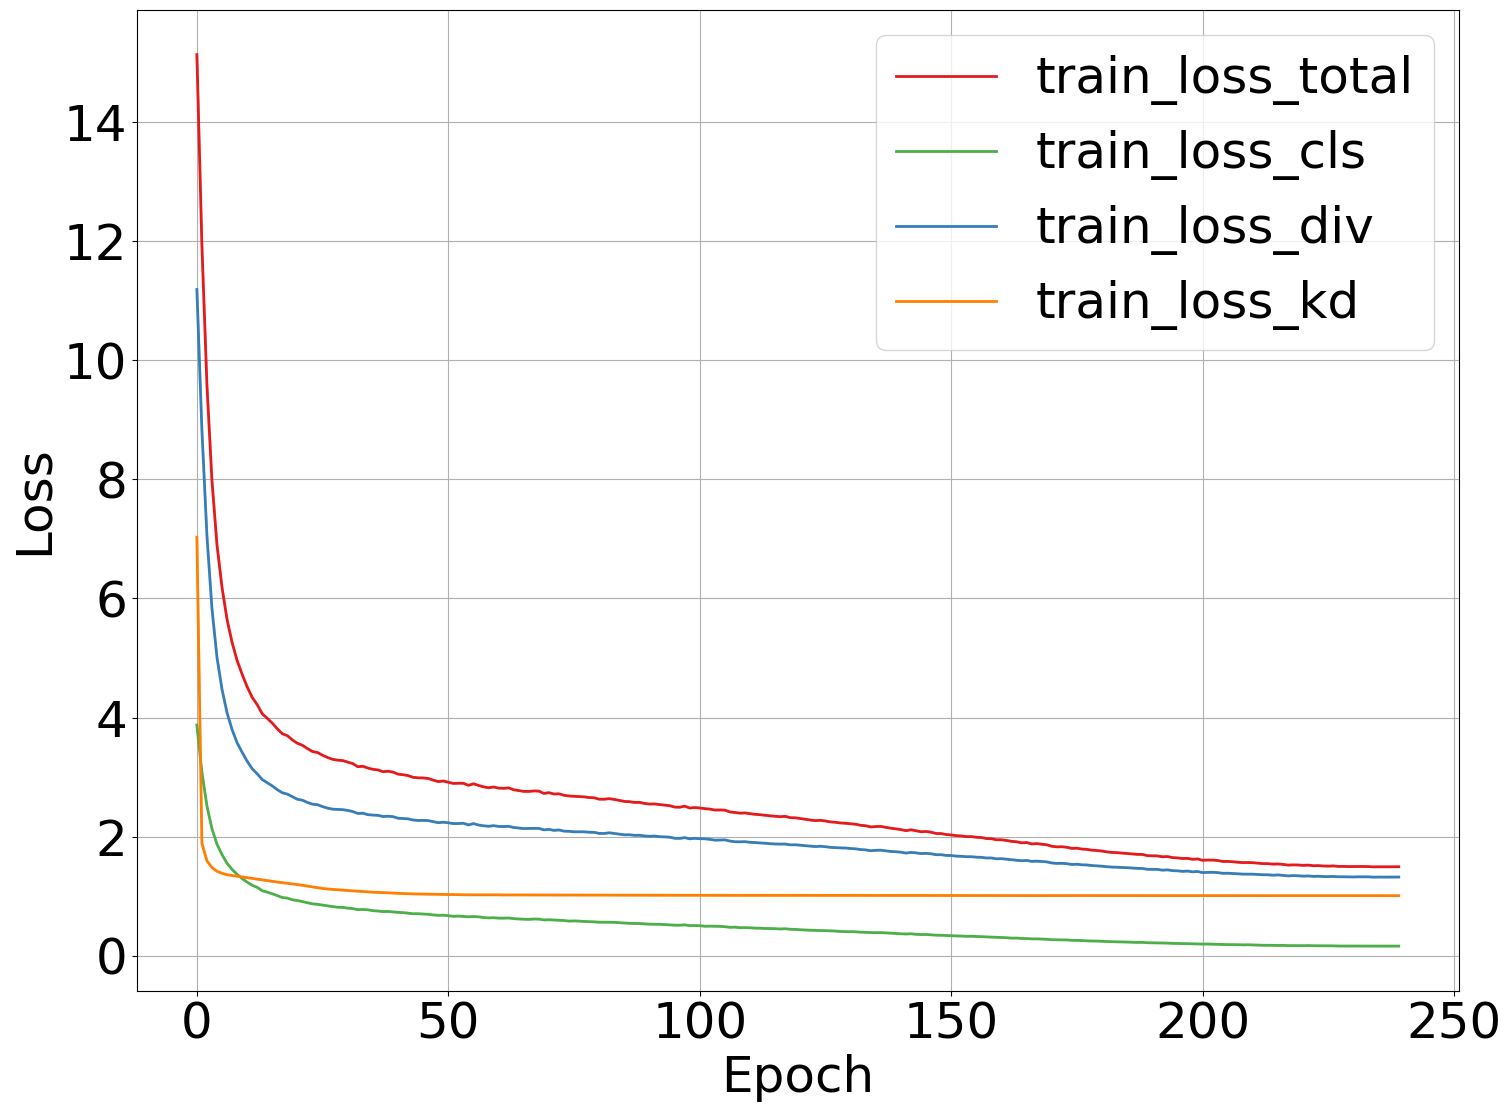

Processing: ResNet14 (Str-KD)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os, json


for idx, (label, paths) in enumerate(files.items()):
    print(f"Processing: {label}")
    if not paths:
        continue   # 空ならスキップ

    if not isinstance(paths, list):
        paths = [paths]

    beta = load_data(os.path.join(root, paths[0]), file="parameters.json")["beta"]

    loss_total = []
    loss_cls = []
    loss_div = []
    loss_kd = []
    loss_kd_group = []
    
    # --- Studentモデル ---
    for path in paths:
        full_path = os.path.join(root, path)
        print(f"Loading from: {full_path}")
        if not os.path.exists(full_path):
            print(f"File not found: {full_path}")
            continue
        data = load_data(full_path) #lossは240エポック分のリスト
        for key in keys:
            loss = data[key]
            if key == "train_loss_total":
                loss_total.append(loss)
            elif key == "train_loss_cls":
                loss_cls.append(loss)
            elif key == "train_loss_div":
                loss_div.append(loss)
            elif key == "train_loss_kd":
                loss_kd.append(loss)
            elif key == "train_loss_kd_group":
                loss_kd_group.append(loss)

    loss_kd = [[x * beta for x in row] for row in loss_kd]
    loss_kd_group = [[x * beta for x in row] for row in loss_kd_group]
                
    plt.close('all')
    plt.figure(figsize=(16, 12))
    plt.rcParams['font.size'] = 36

    idx = 0  # 色を変えるためのインデックス

    for key, loss_data in zip(keys, [loss_total, loss_cls, loss_div, loss_kd, loss_kd_group]):
        if not loss_data:
            continue

        # 各エポックの平均・標準偏差
        min_len = min(len(a) for a in loss_data)
        loss_data = np.array([a[:min_len] for a in loss_data])
        mean_loss = loss_data.mean(axis=0)
        std_loss = loss_data.std(axis=0)

        # 平均＋シャドウ
        plt.plot(mean_loss, label=key, color=col[idx], linewidth=2)
        plt.fill_between(range(len(mean_loss)),
                         mean_loss - std_loss,
                         mean_loss + std_loss,
                         color=col[idx],
                         alpha=0.2)
        idx += 1  # 色を変えるためにインデックスを進める
    
    json_path = os.path.join(root, paths[0], "parameters.json")
    show_json_info(json_path, keys=["model", "distill", "beta", "group_num", "layer_usage"])

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    # plt.title("")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [29]:
loss_kd

[[0.07028017346143722,
  0.018890077893733977,
  0.015941541615724565,
  0.014813322642445564,
  0.01419233668744564,
  0.013855271829664707,
  0.013602969235777855,
  0.013490117515921593,
  0.013359400564432144,
  0.013241699382066726,
  0.01310784032136202,
  0.01299197867691517,
  0.012868673116564752,
  0.012733288769721985,
  0.012621732849478722,
  0.012496794333457947,
  0.01237756548523903,
  0.012274066396355629,
  0.012166766583025455,
  0.012070600258708,
  0.01196026359140873,
  0.011830972071290016,
  0.011704959167540073,
  0.01155888506680727,
  0.011428969189822674,
  0.011301852656304836,
  0.01121129819869995,
  0.011146495868861675,
  0.011073686213493347,
  0.011012637092471123,
  0.010958241761028767,
  0.01090752604842186,
  0.01084706199914217,
  0.010792472779154778,
  0.01073317678809166,
  0.010681510675549507,
  0.01065043781042099,
  0.010609754262268543,
  0.010571221742033959,
  0.010536778822541237,
  0.010480629817247391,
  0.010448887504935264,
  0.010